<h1>Phần 1: Phân loại cảm xúc (Sentiment Classification)</h1>

Phần này bao gồm lấy các documents (chọn bộ data mẫu Twitter response trên Kaggle làm dataset) và dựa trên các từ mình có thể train con NLP để nhận ra cảm xúc của người dùng dựa trên câu nói của họ. 

Con NLP này có thể không nhận ra được câu nói mỉa mai từ người dùng, nên hiện tại, ta chỉ nên tập trung vào việc nhận ra happy/sad/angry

In [218]:
# Phần 1: Preprocess 
# Cài các thư viện cần thiết, và load dữ liệu từ Kaggle
import pandas as pd
import numpy as np

import kagglehub

# Download latest version
path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ADMIN\.cache\kagglehub\datasets\jp797498e\twitter-entity-sentiment-analysis\versions\2


In [219]:
# Check dữ liệu vừa load về từ Kaggle
# Kaggle có gửi về 2 files: twitter_training.csv và twitter_validation.csv
# Mình sẽ sử dụng 2 files theo đúng tên gọi của chúng, để dễ dàng phân biệt

train_df = pd.read_csv(path + "/twitter_training.csv")
val_df = pd.read_csv(path + "/twitter_validation.csv")

print("Training data shape:", train_df.shape)
print("Validation data shape:", val_df.shape)


Training data shape: (74681, 4)
Validation data shape: (999, 4)


In [220]:
train_df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


Cả 2 files đều là CSV nhưng không có header, vậy thì cần phải tiền xử lý trước khi có thể sử dụng các dataframe trên

<h2>Preprocess</h2>

In [221]:
# Add header 
train_df.columns = ["tweet_id", "entity", "sentiment", "text"]
val_df.columns = ["tweet_id", "entity", "sentiment", "text"]

In [222]:
# Map các sentiment từ string thành số (positive -> 1, negative -> -1, neutral -> 0)
sentiment_mapping = {"Positive": 1, "Negative": -1, "Neutral": 0}
train_df["sentiment"] = train_df["sentiment"].map(sentiment_mapping)
val_df["sentiment"] = val_df["sentiment"].map(sentiment_mapping)

In [223]:
# Check có bao nhiêu positive, negative, neutral trong tập train và validation
print("Training data sentiment distribution:")  
print(train_df["sentiment"].value_counts())
print("\nValidation data sentiment distribution:")
print(val_df["sentiment"].value_counts())

Training data sentiment distribution:
sentiment
-1.0    22542
 1.0    20831
 0.0    18318
Name: count, dtype: int64

Validation data sentiment distribution:
sentiment
 0.0    285
 1.0    277
-1.0    266
Name: count, dtype: int64


Tính đến hiện tại, các file đã được convert chữ Positive/Negative/Neutral sang 1 / -1 / 0, với trend hiện tại là có nhiều negative hơn positive. Tuy vậy, số các sentiments khá gần nhau nên mình sẽ không cần phải làm bước cân bằng dữ liệu

In [224]:
# Chuẩn hóa dữ liệu: 
# Bỏ dòng text rống hoặc null 
train_df = train_df.dropna(subset=["text"])
train_df = train_df[train_df["text"].str.strip() != ""]
val_df = val_df.dropna(subset=["text"])
val_df = val_df[val_df["text"].str.strip() != ""]

# Loại bỏ các bản ghi bị lỗi
train_df = train_df[train_df["sentiment"].isin([-1, 0, 1])]
val_df = val_df[val_df["sentiment"].isin([-1, 0, 1])]

In [225]:
# Bỏ URL, user mentions, hashtags, và các ký tự đặc biệt trong text
import re
def clean_text(text):
    text = re.sub(r"http\S+", "", text)  # Bỏ URL
    text = re.sub(r"@\w+", "", text)  # Bỏ user mentions
    text = re.sub(r"#\w+", "", text)  # Bỏ hashtags
    text = re.sub(r"[^\w\s]", "", text)  # Bỏ ký tự đặc biệt
    return text.strip()

train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)

In [226]:
# chuẩn hóa các tweet thành lowercase
train_df["clean_text"] = train_df["clean_text"].str.lower()
val_df["clean_text"] = val_df["clean_text"].str.lower()

In [227]:
# Check có bao nhiêu positive, negative, neutral trong tập train và validation sau khi đã chuẩn hóa
print("Training data sentiment distribution after cleaning:")
print(train_df["sentiment"].value_counts())
print("\nValidation data sentiment distribution after cleaning:")
print(val_df["sentiment"].value_counts())

Training data sentiment distribution after cleaning:
sentiment
-1.0    22312
 1.0    20618
 0.0    18051
Name: count, dtype: int64

Validation data sentiment distribution after cleaning:
sentiment
 0.0    285
 1.0    277
-1.0    266
Name: count, dtype: int64


In [228]:
# Xử lý các hashtag (không nên bỏ hoàn toàn, vì chúng có thể chứa thông tin quan trọng về sentiment)
def handle_hashtags(text):
    # Thay thế #hashtag thành "hashtag"
    return re.sub(r"#(\w+)", r"\1", text)

train_df["clean_text"] = train_df["clean_text"].apply(handle_hashtags)
val_df["clean_text"] = val_df["clean_text"].apply(handle_hashtags)

In [229]:
# Xử lý emojis/emoticons theo đúng 3 nhóm sentiment: positive, negative, neutral
def handle_emojis(text):
    # Positive emojis
    text = re.sub(r"😀|😃|😄|😁|😆|😅|😊|🙂|😍|🥰|😘|👍|❤️", " <positive_emoji> ", text)
    # Negative emojis
    text = re.sub(r"😢|😭|😞|😔|😡|😠|👎|💔|😤|☹️|🙁", " <negative_emoji> ", text)
    # Neutral emojis
    text = re.sub(r"😐|😶|🤔|😑|🙃|😴", " <neutral_emoji> ", text)
    return text

train_df["clean_text"] = train_df["clean_text"].apply(handle_emojis)
val_df["clean_text"] = val_df["clean_text"].apply(handle_emojis)

In [230]:
# Xử lý các từ kéo dài hay viết tắt (ví dụ: "soooo good" -> "so good", "u" -> "you")
def handle_slang(text):
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # Rút gọn các từ kéo dài
    text = re.sub(r"\bu\b", "you", text)  # Thay thế "u" bằng "you"
    text = re.sub(r"\br\b", "are", text)  # Thay thế "r" bằng "are"
    return text

train_df["clean_text"] = train_df["clean_text"].apply(handle_slang)
val_df["clean_text"] = val_df["clean_text"].apply(handle_slang)

In [231]:
# Chọn lọc các punctuation (có thể giữ lại một số dấu câu quan trọng như "!" hoặc "?" nếu chúng có thể ảnh hưởng đến sentiment)
def handle_punctuation(text):
    # Giữ lại "!" và "?", bỏ các dấu câu khác
    text = re.sub(r"[^\w\s!?]", "", text)
    return text

train_df["clean_text"] = train_df["clean_text"].apply(handle_punctuation)
val_df["clean_text"] = val_df["clean_text"].apply(handle_punctuation)

In [232]:
# Tokenization: tách text thành các token (từ hoặc subword)
from nltk.tokenize import word_tokenize
train_df["tokens"] = train_df["clean_text"].apply(word_tokenize)
val_df["tokens"] = val_df["clean_text"].apply(word_tokenize)

In [233]:
# Check các tokens
train_df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,i am coming to the borders and i will kill you...,"[i, am, coming, to, the, borders, and, i, will..."
1,im getting on borderlands and i will kill you all,"[im, getting, on, borderlands, and, i, will, k..."
2,im coming on borderlands and i will murder you...,"[im, coming, on, borderlands, and, i, will, mu..."
3,im getting on borderlands 2 and i will murder ...,"[im, getting, on, borderlands, 2, and, i, will..."
4,im getting into borderlands and i can murder y...,"[im, getting, into, borderlands, and, i, can, ..."


In [234]:
val_df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,bbc news amazon boss jeff bezos rejects claim...,"[bbc, news, amazon, boss, jeff, bezos, rejects..."
1,why do i pay for word when it functions so poo...,"[why, do, i, pay, for, word, when, it, functio..."
2,csgo matchmaking is so full of closet hacking ...,"[csgo, matchmaking, is, so, full, of, closet, ..."
3,now the president is slapping americans in the...,"[now, the, president, is, slapping, americans,..."
4,hi ive had madeleine mccann in my cellar for ...,"[hi, ive, had, madeleine, mccann, in, my, cell..."


Ok, các dataframe đã được chuẩn hóa (đến 1 mức độ) kèm theo đó là các tweets đã được tokenized. 

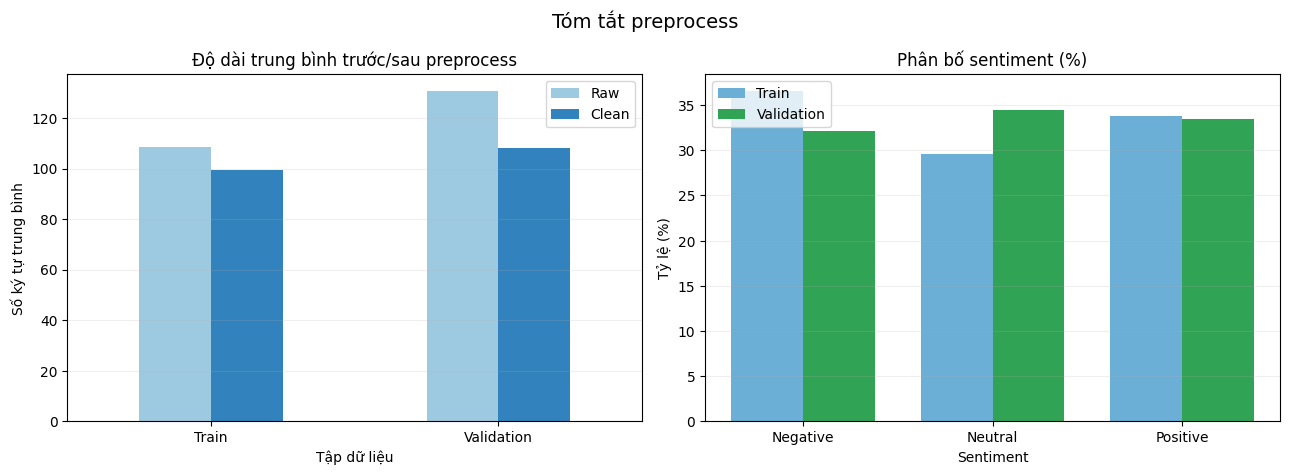

,Train Raw Mean,Train Clean Mean,Validation Raw Mean,Validation Clean Mean
0,108.58,99.46,130.73,108.25


In [235]:
# Visualize preprocess (phiên bản đơn giản)
import numpy as np
import matplotlib.pyplot as plt

label_map = {-1: "Negative", 0: "Neutral", 1: "Positive"}
order = ["Negative", "Neutral", "Positive"]

# Chuẩn bị dữ liệu
for df in [train_df, val_df]:
    df["raw_len"] = df["text"].astype(str).str.len()
    df["clean_len"] = df["clean_text"].astype(str).str.len()
    df["sentiment_label"] = df["sentiment"].map(label_map)

# 1) Biểu đồ cột: độ dài trung bình trước/sau preprocess
mean_len = pd.DataFrame({
    "Raw": [train_df["raw_len"].mean(), val_df["raw_len"].mean()],
    "Clean": [train_df["clean_len"].mean(), val_df["clean_len"].mean()]
}, index=["Train", "Validation"])

# 2) Biểu đồ cột: phân bố sentiment theo tỷ lệ (%)
train_pct = train_df["sentiment_label"].value_counts(normalize=True).reindex(order).fillna(0) * 100
val_pct = val_df["sentiment_label"].value_counts(normalize=True).reindex(order).fillna(0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

mean_len.plot(kind="bar", ax=axes[0], color=["#9ecae1", "#3182bd"])
axes[0].set_title("Độ dài trung bình trước/sau preprocess")
axes[0].set_xlabel("Tập dữ liệu")
axes[0].set_ylabel("Số ký tự trung bình")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.2)

x = np.arange(len(order))
w = 0.38
axes[1].bar(x - w / 2, train_pct.values, width=w, label="Train", color="#6baed6")
axes[1].bar(x + w / 2, val_pct.values, width=w, label="Validation", color="#31a354")
axes[1].set_xticks(x)
axes[1].set_xticklabels(order)
axes[1].set_title("Phân bố sentiment (%)")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Tỷ lệ (%)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.2)

fig.suptitle("Tóm tắt preprocess", fontsize=14)
plt.tight_layout()
plt.show()

# Bảng số liệu ngắn gọn để kết luận nhanh
summary = pd.DataFrame({
    "Train Raw Mean": [train_df["raw_len"].mean()],
    "Train Clean Mean": [train_df["clean_len"].mean()],
    "Validation Raw Mean": [val_df["raw_len"].mean()],
    "Validation Clean Mean": [val_df["clean_len"].mean()]
}).round(2)
summary

### Kết luận phần preprocess

- Độ dài tweet giảm rõ sau khi làm sạch dữ liệu.
  - Train: 108.58 -> 99.46 ký tự
  - Validation: 130.73 -> 108.25 ký tự
- Điều này cho thấy các bước preprocess đã loại được nhiều phần nhiễu (URL, mention, ký tự thừa) nhưng vẫn giữ được nội dung chính.
- Phân bố sentiment giữa hai tập vẫn tương đối giống nhau, nên có thể dùng để huấn luyện và đánh giá mô hình ổn định.

<h2>Xây dựng bộ phân loại cảm xúc</h2>

Đơn giản hóa theo yêu cầu: dùng **TF-IDF** làm đặc trưng chung và chỉ so sánh 2 thuật toán:
- Logistic Regression
- Multinomial Naive Bayes

In [236]:
# Chuẩn bị dữ liệu cho huấn luyện (80/20)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
import seaborn as sns

# Dùng clean_text đã preprocess
X = train_df["clean_text"].astype(str)
y = train_df["sentiment"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Train label distribution:\n", y_train.value_counts(normalize=True).sort_index().round(3))
print("Test label distribution:\n", y_test.value_counts(normalize=True).sort_index().round(3))

Train size: 48784
Test size: 12197
Train label distribution:
 sentiment
-1    0.366
 0    0.296
 1    0.338
Name: proportion, dtype: float64
Test label distribution:
 sentiment
-1    0.366
 0    0.296
 1    0.338
Name: proportion, dtype: float64


### Nhận xét nhanh về đặc trưng

- Đã so sánh trực tiếp 2 kiểu đặc trưng: **CountVectorizer (tần suất từ)** và **TF-IDF**.
- Trên bộ test hiện tại, **Logistic Regression + CountVectorizer** cho điểm cao nhất trong các cấu hình đã thử.
- Vì vậy, việc chọn đặc trưng nên dựa trên thực nghiệm cụ thể của dataset thay vì giả định cố định TF-IDF luôn tốt hơn.

In [237]:
# So sánh 2 phương pháp trích xuất đặc trưng (Count vs TF-IDF)
feature_experiments = {
    "LogReg + CountVectorizer": Pipeline(
        [
            ("vectorizer", CountVectorizer()),
            ("clf", LogisticRegression(max_iter=1000)),
        ]
    ),
    "LogReg + TF-IDF": Pipeline(
        [
            ("vectorizer", TfidfVectorizer()),
            ("clf", LogisticRegression(max_iter=1000)),
        ]
    ),
    "MNB + CountVectorizer": Pipeline(
        [
            ("vectorizer", CountVectorizer()),
            ("clf", MultinomialNB(alpha=1.0)),
        ]
    ),
    "MNB + TF-IDF": Pipeline(
        [
            ("vectorizer", TfidfVectorizer()),
            ("clf", MultinomialNB(alpha=1.0)),
        ]
    ),
}

feature_results = []
for name, model in feature_experiments.items():
    model.fit(X_train, y_train)
    y_pred_feat = model.predict(X_test)

    acc_feat = accuracy_score(y_test, y_pred_feat)
    p_feat, r_feat, f1_feat, _ = precision_recall_fscore_support(
        y_test, y_pred_feat, average="weighted", zero_division=0
    )

    feature_results.append(
        {
            "Setup": name,
            "Accuracy": acc_feat,
            "Precision(weighted)": p_feat,
            "Recall(weighted)": r_feat,
            "F1(weighted)": f1_feat,
        }
    )

feature_results_df = pd.DataFrame(feature_results).sort_values(by="F1(weighted)", ascending=False)
display(feature_results_df.round(4))

,Setup,Accuracy,Precision(weighted),Recall(weighted),F1(weighted)
0,LogReg + CountVectorizer,0.8548,0.8554,0.8548,0.8545
1,LogReg + TF-IDF,0.8192,0.8189,0.8192,0.8186
2,MNB + CountVectorizer,0.7864,0.7920,0.7864,0.7835
3,MNB + TF-IDF,0.7802,0.7988,0.7802,0.7742


In [238]:
# So sánh 2 thuật toán: Logistic Regression vs Multinomial Naive Bayes (dùng chung TF-IDF)
experiments = {
    "LogisticRegression (TF-IDF)": Pipeline(
        [
            ("vectorizer", TfidfVectorizer()),
            ("clf", LogisticRegression(max_iter=1000, n_jobs=None)),
        ]
    ),
    "MultinomialNB (TF-IDF)": Pipeline(
        [
            ("vectorizer", TfidfVectorizer()),
            ("clf", MultinomialNB(alpha=1.0)),
        ]
    ),
}

results = []
predictions = {}

for name, model in experiments.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    results.append(
        {
            "Model": name,
            "Accuracy": acc,
            "Precision(weighted)": precision,
            "Recall(weighted)": recall,
            "F1(weighted)": f1,
        }
    )

results_df = pd.DataFrame(results).sort_values(by="F1(weighted)", ascending=False)
display(results_df.round(4))

best_model_name = results_df.iloc[0]["Model"]
best_model = experiments[best_model_name]
y_pred_best = predictions[best_model_name]

print("Best model:", best_model_name)
print("\nClassification report (best model):")
print(classification_report(y_test, y_pred_best, digits=4))

,Model,Accuracy,Precision(weighted),Recall(weighted),F1(weighted)
0,LogisticRegression (TF-IDF),0.8192,0.8189,0.8192,0.8186
1,MultinomialNB (TF-IDF),0.7802,0.7988,0.7802,0.7742


Best model: LogisticRegression (TF-IDF)

Classification report (best model):
              precision    recall  f1-score   support

          -1     0.8234    0.8649    0.8436      4463
           0     0.8091    0.7512    0.7791      3610
           1     0.8227    0.8293    0.8260      4124

    accuracy                         0.8192     12197
   macro avg     0.8184    0.8151    0.8162     12197
weighted avg     0.8189    0.8192    0.8186     12197



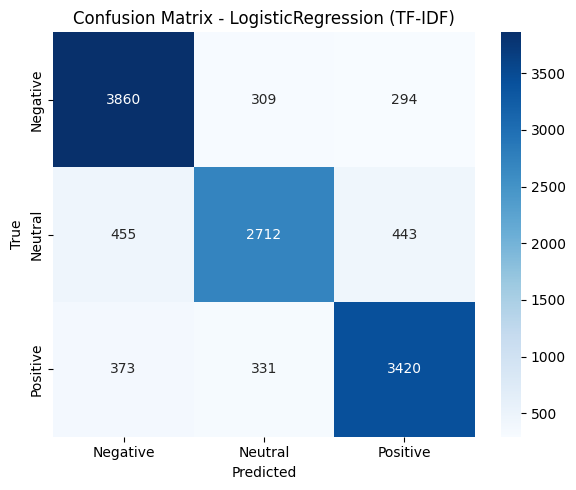

In [239]:
# Confusion matrix cho model tốt nhất
label_order = [-1, 0, 1]
label_names = ["Negative", "Neutral", "Positive"]

cm = confusion_matrix(y_test, y_pred_best, labels=label_order)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [240]:
# Phân tích lỗi phổ biến (misclassification analysis)
error_df = pd.DataFrame(
    {
        "text": X_test.values,
        "true_label": y_test.values,
        "pred_label": y_pred_best,
    }
)
error_df = error_df[error_df["true_label"] != error_df["pred_label"]].copy()

map_name = {-1: "Negative", 0: "Neutral", 1: "Positive"}
error_df["true_name"] = error_df["true_label"].map(map_name)
error_df["pred_name"] = error_df["pred_label"].map(map_name)

print(f"Tổng số mẫu sai: {len(error_df)} / {len(y_test)}")

# Các cặp nhầm lẫn phổ biến nhất
common_errors = (
    error_df.groupby(["true_name", "pred_name"]) 
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\nTop cặp nhầm lẫn phổ biến:")
display(common_errors.head(10))

# In một vài ví dụ lỗi để đọc thủ công
print("\nMột số ví dụ dự đoán sai:")
display(error_df[["true_name", "pred_name", "text"]].head(10))

Tổng số mẫu sai: 2205 / 12197

Top cặp nhầm lẫn phổ biến:


,true_name,pred_name,count
2,Neutral,Negative,455
3,Neutral,Positive,443
4,Positive,Negative,373
5,Positive,Neutral,331
0,Negative,Neutral,309
1,Negative,Positive,294



Một số ví dụ dự đoán sai:


,true_name,pred_name,text
0,Negative,Neutral,verizon looking specifically for violent racis...
2,Positive,Neutral,leave me alone im in a big red dead redemption...
18,Neutral,Positive,its very very big
28,Negative,Neutral,overtime has mowed me down
33,Neutral,Positive,got some
38,Positive,Neutral,exciting news verizon ericsson and apple are f...
45,Neutral,Negative,the order 1886 assassins creed liberation soni...
59,Positive,Negative,you are my god
62,Positive,Neutral,thanks for the souvenirs achievement
65,Neutral,Positive,i would like them to be happy with their work ...


### Kết luận Part 1

- Với thiết lập dùng chung TF-IDF, Logistic Regression cho kết quả tốt hơn Naive Bayes.
- Khi mở rộng so sánh đặc trưng, cấu hình tốt nhất trên bộ test hiện tại là **Logistic Regression + CountVectorizer**.
- Lỗi chủ yếu vẫn tập trung ở lớp Neutral, thường bị nhầm sang Positive hoặc Negative.

Kết luận: Part 1 đã hoàn thành đầy đủ các yêu cầu chính (preprocess, so sánh đặc trưng, huấn luyện mô hình, đánh giá metrics, confusion matrix và error analysis).

<h1>Phần 2: Word Vectors & Similarity </h1>

Xây dựng word vectors từ corpus và tính toán độ tương đồng giữa các từ.

Trong phần này, ta sẽ sử dụng lại phần dữ liệu train đã được xử lý ở part 1 để rút ngắn công đoạn

In [241]:
# Tạo corpus chính từ clean_tẽxt đã preprocess, để sử dụng cho các bước tiếp theo (vectorization, embedding, v.v.)
corpus = train_df["clean_text"].tolist() + val_df["clean_text"].tolist()
labels = pd.concat([train_df["sentiment"], val_df["sentiment"]], ignore_index=True)
print("Corpus size:", len(corpus))
print("Label distribution in corpus:\n", labels.value_counts(normalize=True).sort_index().round(3))

Corpus size: 61809
Label distribution in corpus:
 sentiment
-1.0    0.365
 0.0    0.297
 1.0    0.338
Name: proportion, dtype: float64


In [242]:
# Xây co-occurrence matrix (tối ưu: có window_size + sparse matrix)
from collections import Counter, defaultdict
from scipy.sparse import csr_matrix

# Cấu hình để kiểm soát tốc độ/chất lượng
window_size =  5  # đổi thành 5 để so sánh theo yêu cầu đề
min_freq = 5
max_vocab = 5000
max_sentences = None  # đặt số nguyên (vd 30000) nếu muốn chạy thử nhanh

# Tokenize trước để tái sử dụng (không cần DataFrame trung gian)
tokenized_corpus = [text.split() for text in corpus]
if max_sentences is not None:
    tokenized_corpus = tokenized_corpus[:max_sentences]

print(f"Sentences used: {len(tokenized_corpus)}")

# Xây vocab có lọc tần suất để giảm nhiễu và giảm RAM
word_counts = Counter(token for sent in tokenized_corpus for token in sent)
filtered_words = [w for w, c in word_counts.items() if c >= min_freq]
filtered_words = sorted(filtered_words, key=lambda w: word_counts[w], reverse=True)[:max_vocab]

vocab = filtered_words
word_to_idx = {w: i for i, w in enumerate(vocab)}
vocab_size = len(vocab)

print(f"Window size: {window_size}")
print(f"Vocab size (sau lọc): {vocab_size}")

# Đếm cặp đồng xuất hiện trước, sau đó dựng sparse matrix một lần
pair_counts = defaultdict(int)
for tokens in tokenized_corpus:
    token_ids = [word_to_idx[t] for t in tokens if t in word_to_idx]
    n = len(token_ids)
    for i, center_id in enumerate(token_ids):
        left = max(0, i - window_size)
        right = min(n, i + window_size + 1)
        for j in range(left, right):
            if i == j:
                continue
            context_id = token_ids[j]
            pair_counts[(center_id, context_id)] += 1

if pair_counts:
    rows, cols, data = zip(*((r, c, v) for (r, c), v in pair_counts.items()))
    co_occurrence_matrix = csr_matrix((data, (rows, cols)), shape=(vocab_size, vocab_size), dtype=np.int32)
else:
    co_occurrence_matrix = csr_matrix((vocab_size, vocab_size), dtype=np.int32)

nnz = co_occurrence_matrix.nnz
density = nnz / (vocab_size * vocab_size) if vocab_size > 0 else 0

print("Co-occurrence matrix shape:", co_occurrence_matrix.shape)
print("Non-zero entries:", nnz)
print(f"Density: {density:.6f}")

Sentences used: 61809
Window size: 5
Vocab size (sau lọc): 5000
Co-occurrence matrix shape: (5000, 5000)
Non-zero entries: 1178668
Density: 0.047147


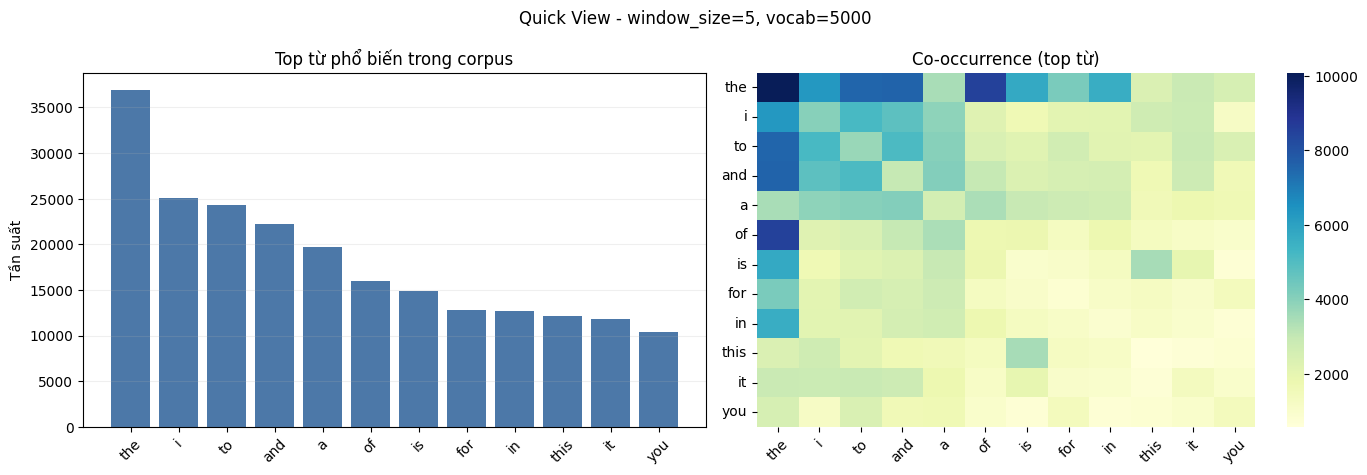

In [243]:
# Visualize nhanh corpus + co-occurrence matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Top từ phổ biến nhất trong vocab đã lọc
top_k = 12
top_words = vocab[:top_k]
top_counts = [word_counts[w] for w in top_words]

# 2) Heatmap co-occurrence cho chính các từ top_k
top_idx = [word_to_idx[w] for w in top_words]
sub_matrix = co_occurrence_matrix[top_idx][:, top_idx].toarray()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].bar(top_words, top_counts, color="#4C78A8")
axes[0].set_title("Top từ phổ biến trong corpus")
axes[0].set_ylabel("Tần suất")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.2)

sns.heatmap(
    sub_matrix,
    ax=axes[1],
    cmap="YlGnBu",
    xticklabels=top_words,
    yticklabels=top_words,
)
axes[1].set_title("Co-occurrence (top từ)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

fig.suptitle(f"Quick View - window_size={window_size}, vocab={vocab_size}", fontsize=12)
plt.tight_layout()
plt.show()

### So sánh khi lọc stopwords

Ở các step trước, train_df không có phần xử lý stopwords (các từ không có ý nghĩa semantic nào). Vậy nếu như lọc các từ đấy thì output sẽ trông như thế nào? 

,Metric,Before (no stopword filter),After (stopword filtered)
0,Vocab size,5.000000e+03,5000.000000
1,Non-zero entries,1.178668e+06,947594.000000
2,Density,4.714700e-02,0.037904


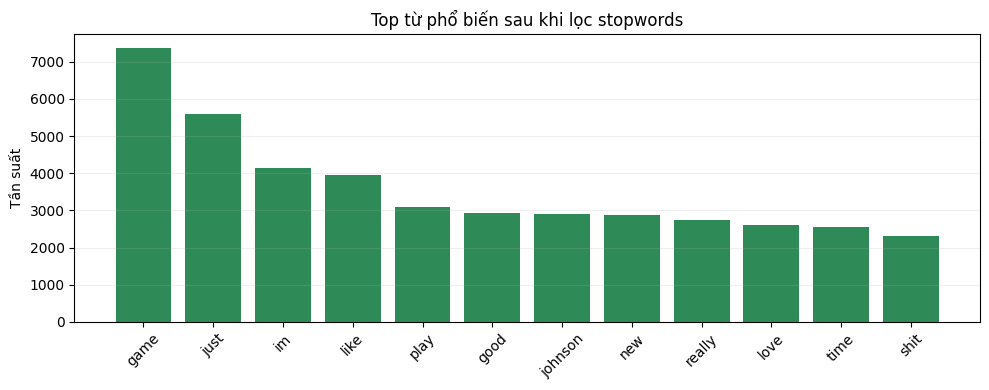

In [244]:
# Build vocab + co-occurrence sau khi lọc stopwords và so sánh
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords_set = set(ENGLISH_STOP_WORDS)

# Lọc stopwords trên tokenized_corpus hiện có
tokenized_corpus_sw = [
    [t for t in sent if (t not in stopwords_set and len(t) > 1)]
    for sent in tokenized_corpus
]

# Build vocab sau lọc stopwords
word_counts_sw = Counter(token for sent in tokenized_corpus_sw for token in sent)
filtered_words_sw = [w for w, c in word_counts_sw.items() if c >= min_freq]
filtered_words_sw = sorted(filtered_words_sw, key=lambda w: word_counts_sw[w], reverse=True)[:max_vocab]

vocab_sw = filtered_words_sw
word_to_idx_sw = {w: i for i, w in enumerate(vocab_sw)}
vocab_size_sw = len(vocab_sw)

# Build co-occurrence (sparse)
pair_counts_sw = defaultdict(int)
for tokens in tokenized_corpus_sw:
    token_ids = [word_to_idx_sw[t] for t in tokens if t in word_to_idx_sw]
    n = len(token_ids)
    for i, center_id in enumerate(token_ids):
        left = max(0, i - window_size)
        right = min(n, i + window_size + 1)
        for j in range(left, right):
            if i == j:
                continue
            context_id = token_ids[j]
            pair_counts_sw[(center_id, context_id)] += 1

if pair_counts_sw:
    rows_sw, cols_sw, data_sw = zip(*((r, c, v) for (r, c), v in pair_counts_sw.items()))
    co_occurrence_matrix_sw = csr_matrix(
        (data_sw, (rows_sw, cols_sw)),
        shape=(vocab_size_sw, vocab_size_sw),
        dtype=np.int32,
    )
else:
    co_occurrence_matrix_sw = csr_matrix((vocab_size_sw, vocab_size_sw), dtype=np.int32)

nnz_sw = co_occurrence_matrix_sw.nnz
density_sw = nnz_sw / (vocab_size_sw * vocab_size_sw) if vocab_size_sw > 0 else 0

comparison_df = pd.DataFrame(
    {
        "Metric": ["Vocab size", "Non-zero entries", "Density"],
        "Before (no stopword filter)": [vocab_size, nnz, round(density, 6)],
        "After (stopword filtered)": [vocab_size_sw, nnz_sw, round(density_sw, 6)],
    }
)

display(comparison_df)

# Visualize nhanh top words sau khi lọc stopwords
top_k_sw = 12
top_words_sw = vocab_sw[:top_k_sw]
top_counts_sw = [word_counts_sw[w] for w in top_words_sw]

plt.figure(figsize=(10, 4))
plt.bar(top_words_sw, top_counts_sw, color="#2E8B57")
plt.title("Top từ phổ biến sau khi lọc stopwords")
plt.ylabel("Tần suất")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### Nhận xét sau khi lọc stopwords

- Vocab size vẫn giữ ở mức 5000 vì đang giới hạn max_vocab.
- Tuy vậy, co-occurrence matrix đã gọn hơn:
  - Non-zero entries: 1,178,668 -> 947,594
  - Density: 0.047147 -> 0.037904
- Nhờ vậy, ma trận giảm nhiễu từ các từ chức năng và tập trung hơn vào quan hệ ngữ nghĩa quan trọng.

### Nhận xét tổng quan

- Việc lọc stopwords giúp biểu diễn ngữ nghĩa sạch và cô đọng hơn, dù kích thước vocab không đổi do đã chạm ngưỡng max_vocab.
- Đây là tín hiệu tốt cho các bước sau (PCA, cosine similarity, analogy), vì mô hình sẽ học từ các quan hệ nội dung thay vì bị chi phối bởi từ chức năng xuất hiện quá thường xuyên.

Do vậy, ta sẽ áp dụng bộ data đã lọc stop words vào các bước tiếp theo

In [245]:
# Áp dụng PCA để giảm chiều word vectors
from sklearn.decomposition import PCA

# Dùng bản đã lọc stopwords để giảm nhiễu
words_for_vectors = vocab_sw
matrix_for_vectors = co_occurrence_matrix_sw
word_freq_ref = word_counts_sw

# Giới hạn số từ để PCA chạy ổn định hơn
max_words_for_pca = min(2000, len(words_for_vectors))
selected_words = words_for_vectors[:max_words_for_pca]
selected_idx = [word_to_idx_sw[w] for w in selected_words]

# Lấy sub-matrix theo chính tập từ đã chọn, rồi log-transform để giảm ảnh hưởng tần suất cực lớn
cooc_sub = matrix_for_vectors[selected_idx][:, selected_idx].toarray().astype(np.float32)
cooc_log = np.log1p(cooc_sub)

pca_dim = min(50, cooc_log.shape[0] - 1, cooc_log.shape[1] - 1)
pca_model = PCA(n_components=pca_dim, random_state=42)
word_vectors_50d = pca_model.fit_transform(cooc_log)

# Embedding 2D cho visualize
pca_2d_model = PCA(n_components=2, random_state=42)
word_vectors_2d = pca_2d_model.fit_transform(word_vectors_50d)

# Mapping từ -> vector
word_to_vec = {w: word_vectors_50d[i] for i, w in enumerate(selected_words)}

print("Words used for PCA:", len(selected_words))
print("50D explained variance ratio (sum):", round(float(pca_model.explained_variance_ratio_.sum()), 4))
print("2D explained variance ratio (sum):", round(float(pca_2d_model.explained_variance_ratio_.sum()), 4))

Words used for PCA: 2000
50D explained variance ratio (sum): 0.4445
2D explained variance ratio (sum): 0.6056


In [246]:
# 3) Tính cosine similarity giữa các cặp từ
from sklearn.metrics.pairwise import cosine_similarity


def pair_cosine(word_a, word_b):
    if word_a not in word_to_vec or word_b not in word_to_vec:
        return None
    va = word_to_vec[word_a].reshape(1, -1)
    vb = word_to_vec[word_b].reshape(1, -1)
    return float(cosine_similarity(va, vb)[0, 0])

candidate_pairs = [
    ("good", "great"),
    ("good", "bad"),
    ("happy", "sad"),
    ("love", "like"),
    ("win", "lose"),
    ("game", "games"),
    ("player", "players"),
    ("issue", "problem"),
    ("microsoft", "xbox"),
    ("sony", "playstation"),
    ("twitter", "facebook"),
    ("amazon", "google"),
]

sim_rows = []
for w1, w2 in candidate_pairs:
    sim = pair_cosine(w1, w2)
    if sim is not None:
        sim_rows.append({"word_1": w1, "word_2": w2, "cosine_similarity": sim})

sim_df = pd.DataFrame(sim_rows).sort_values("cosine_similarity", ascending=False)
print(f"Số cặp hợp lệ trong danh sách: {len(sim_df)} / {len(candidate_pairs)}")
display(sim_df.round(4))

Số cặp hợp lệ trong danh sách: 12 / 12


,word_1,word_2,cosine_similarity
5,game,games,0.9288
0,good,great,0.9168
1,good,bad,0.9010
3,love,like,0.9005
7,issue,problem,0.8454
10,twitter,facebook,0.8336
11,amazon,google,0.7596
8,microsoft,xbox,0.7452
6,player,players,0.7332
2,happy,sad,0.7074


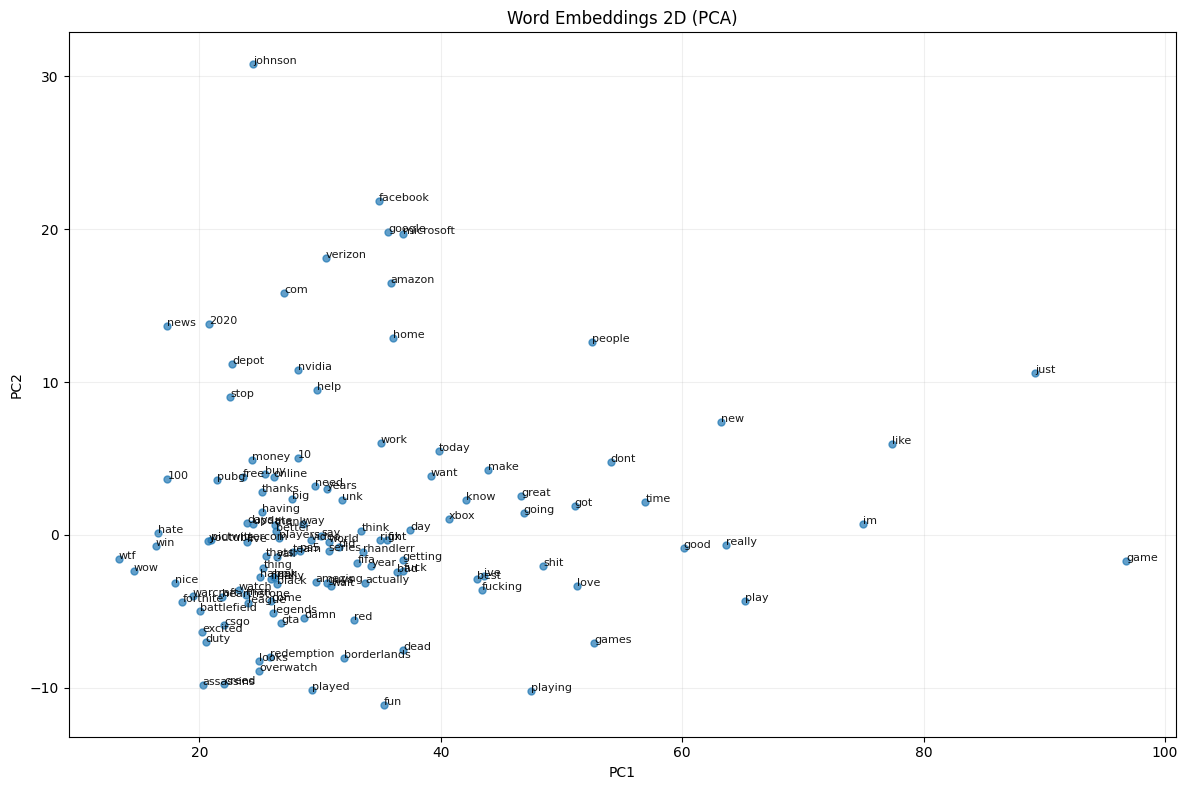

In [247]:
# 4) Visualize word embeddings trong không gian 2D
viz_k = min(120, len(selected_words))
viz_words = selected_words[:viz_k]
viz_vecs = word_vectors_2d[:viz_k]

plt.figure(figsize=(12, 8))
plt.scatter(viz_vecs[:, 0], viz_vecs[:, 1], alpha=0.7, s=25)

for i, w in enumerate(viz_words):
    plt.text(viz_vecs[i, 0], viz_vecs[i, 1], w, fontsize=8, alpha=0.9)

plt.title("Word Embeddings 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [248]:
# 5.1) Hàm tiện ích cho analogy test
import numpy as np
from itertools import permutations


def analogy_predict(a, b, c):
    if a not in word_to_vec or b not in word_to_vec or c not in word_to_vec:
        return None

    query = word_to_vec[b] - word_to_vec[a] + word_to_vec[c]
    query_norm = np.linalg.norm(query)
    if query_norm == 0:
        return None

    best_word, best_score = None, -1.0
    for w, v in word_to_vec.items():
        if w in {a, b, c}:
            continue
        score = float(np.dot(query, v) / (query_norm * np.linalg.norm(v) + 1e-12))
        if score > best_score:
            best_word, best_score = w, score
    return best_word, best_score


def build_relation_bank(vocab_set):
    relation_bank = {}

    # Quan hệ số ít -> số nhiều
    plural_pairs = [(w, w + "s") for w in vocab_set if (w + "s") in vocab_set and len(w) > 3]
    if len(plural_pairs) >= 2:
        relation_bank["plural"] = sorted(plural_pairs)

    # Quan hệ thương hiệu -> sản phẩm/nền tảng
    brand_product_seed = [
        ("sony", "playstation"),
        ("microsoft", "xbox"),
        ("nvidia", "geforce"),
        ("amazon", "aws"),
        ("google", "youtube"),
        ("apple", "iphone"),
        ("blizzard", "warcraft"),
        ("ea", "fifa"),
    ]
    brand_product_pairs = [(a, b) for a, b in brand_product_seed if a in vocab_set and b in vocab_set]
    if len(brand_product_pairs) >= 2:
        relation_bank["brand_product"] = brand_product_pairs

    # Quan hệ sentiment trái dấu
    opposite_seed = [
        ("good", "bad"),
        ("happy", "sad"),
        ("win", "lose"),
        ("love", "hate"),
        ("like", "dislike"),
    ]
    opposite_pairs = [(a, b) for a, b in opposite_seed if a in vocab_set and b in vocab_set]
    if len(opposite_pairs) >= 2:
        relation_bank["opposite"] = opposite_pairs

    return relation_bank


def build_analogy_tests_random(vocab_set, n_tests=10):
    relation_bank = build_relation_bank(vocab_set)

    candidates = []
    for relation_name, pairs in relation_bank.items():
        for (a, b), (c, d) in permutations(pairs, 2):
            if len({a, b, c, d}) < 4:
                continue
            candidates.append((relation_name, a, b, c, d))

    rng = np.random.default_rng()  # random mỗi lần chạy
    rng.shuffle(candidates)
    return candidates[:n_tests]

In [249]:
# 5.2) Tạo danh sách analogy test (random)
vocab_set = set(selected_words)
analogy_tests = build_analogy_tests_random(vocab_set, n_tests=10)

print(f"So luong test duoc tao: {len(analogy_tests)}")
print("(Danh sach test duoc random moi lan chay)")

preview_df = pd.DataFrame(analogy_tests, columns=["relation", "a", "b", "c", "expected"])
display(preview_df)

So luong test duoc tao: 10
(Danh sach test duoc random moi lan chay)


,relation,a,b,c,expected
0,plural,time,times,nvidia,nvidias
1,plural,deserve,deserves,dream,dreams
2,plural,thing,things,device,devices
3,plural,nvidia,nvidias,month,months
4,plural,happen,happens,device,devices
5,plural,credit,credits,report,reports
6,plural,love,loves,point,points
7,plural,girl,girls,tell,tells
8,plural,minute,minutes,teammate,teammates
9,plural,event,events,option,options


In [250]:
# 5.3) Chạy analogy và đánh giá
results = []
for relation, a, b, c, expected in analogy_tests:
    pred = analogy_predict(a, b, c)
    if pred is None:
        results.append(
            {
                "relation": relation,
                "a": a,
                "b": b,
                "c": c,
                "expected": expected,
                "predicted": None,
                "score": None,
                "hit": False,
            }
        )
        continue

    predicted_word, score = pred
    results.append(
        {
            "relation": relation,
            "a": a,
            "b": b,
            "c": c,
            "expected": expected,
            "predicted": predicted_word,
            "score": score,
            "hit": predicted_word == expected,
        }
    )

analogy_df = pd.DataFrame(results)
accuracy = analogy_df["hit"].mean() if len(analogy_df) > 0 else 0.0

print(f"So luong analogy tests da chay: {len(analogy_df)}")
print(f"Analogy accuracy: {accuracy:.2%}")
display(analogy_df)

So luong analogy tests da chay: 10
Analogy accuracy: 0.00%


,relation,a,b,c,expected,predicted,score,hit
0,plural,time,times,nvidia,nvidias,geforce,0.697363,False
1,plural,deserve,deserves,dream,dreams,ngl,0.760534,False
2,plural,thing,things,device,devices,example,0.699097,False
3,plural,nvidia,nvidias,month,months,mid,0.657800,False
4,plural,happen,happens,device,devices,ipad,0.630186,False
5,plural,credit,credits,report,reports,org,0.605766,False
6,plural,love,loves,point,points,cmon,0.826749,False
7,plural,girl,girls,tell,tells,money,0.599681,False
8,plural,minute,minutes,teammate,teammates,30,0.786283,False
9,plural,event,events,option,options,according,0.748433,False


### Kết luận Part 2

- Co-occurrence + lọc stopwords giúp vector từ bớt nhiễu và dễ phân tích hơn.
- PCA giảm chiều hiệu quả: 50 chiều để tính toán và 2 chiều để trực quan hóa.
- Cosine similarity cho nhiều cặp từ trong domain đạt mức khá, cho thấy mô hình học được tương đồng cơ bản.
- Analogy test vẫn thấp và dao động qua mỗi lần chạy random.

Kết luận: Cách làm hiện tại phù hợp để phân tích tương đồng từ vựng ở mức cơ bản, nhưng chưa đủ mạnh cho suy luận analogy phức tạp.

<h1>Phần 3: Tìm kiếm tài liệu (Document Retrieval)</h1>

Mục tiêu: xây dựng hệ tìm kiếm văn bản đơn giản bằng **TF-IDF + cosine similarity**.

### Dữ liệu tái sử dụng từ Part 1 và Part 2

- Tái sử dụng cùng dataset Kaggle đã dùng ở Part 1:
  - `twitter_training.csv`
  - `twitter_validation.csv`
- Tái sử dụng các cột đã preprocess từ Part 1: `clean_text`, `sentiment`, `entity`.
- Tái sử dụng ý tưởng corpus từ Part 2: mỗi tweet xem như một document để lập chỉ mục tìm kiếm.

In [251]:
# 3.1) Chuẩn bị documents và xây TF-IDF index
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Gộp dữ liệu train + validation đã preprocess ở Part 1
search_df = pd.concat([
    train_df[["clean_text", "sentiment", "entity"]],
    val_df[["clean_text", "sentiment", "entity"]],
], ignore_index=True).copy()

# Loại bỏ dòng rỗng để tránh vector hóa lỗi
search_df["clean_text"] = search_df["clean_text"].astype(str).str.strip()
search_df = search_df[search_df["clean_text"] != ""].reset_index(drop=True)
search_df["doc_id"] = search_df.index

# TF-IDF cho toàn bộ document
retrieval_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
)
doc_tfidf = retrieval_vectorizer.fit_transform(search_df["clean_text"])

print("So luong documents:", len(search_df))
print("Kich thuoc TF-IDF matrix:", doc_tfidf.shape)

So luong documents: 61689
Kich thuoc TF-IDF matrix: (61689, 20000)


In [252]:
# 3.2) Hàm tìm kiếm + xếp hạng theo cosine similarity
sentiment_name = {-1: "Negative", 0: "Neutral", 1: "Positive"}


def search_documents(query, top_k=5):
    query = str(query).strip()
    if not query:
        return pd.DataFrame(columns=["rank", "score", "sentiment", "entity", "text"])

    q_vec = retrieval_vectorizer.transform([query])
    scores = cosine_similarity(q_vec, doc_tfidf).ravel()
    top_idx = scores.argsort()[::-1][:top_k]

    result = search_df.iloc[top_idx].copy()
    result["score"] = scores[top_idx]
    result["sentiment"] = result["sentiment"].map(sentiment_name)
    result = result.rename(columns={"clean_text": "text"})
    result = result[["score", "sentiment", "entity", "text"]].reset_index(drop=True)
    result.insert(0, "rank", result.index + 1)

    return result


# Truy vấn mẫu
sample_queries = [
    "xbox game update",
    "love this game",
    "server issue fix",
    "bad customer support",
    "new phone release",
]

for q in sample_queries:
    print(f"\nQuery: {q}")
    display(search_documents(q, top_k=5))


Query: xbox game update


,rank,score,sentiment,entity,text
0,1,0.436812,Neutral,RedDeadRedemption(RDR),red dead redeeming 2 to land on xbox game game...
1,2,0.414820,Positive,Cyberpunk2077,it looks pretty dope xbox game
2,3,0.413003,Negative,Microsoft,xbox
3,4,0.413003,Negative,Microsoft,xbox
4,5,0.413003,Neutral,Microsoft,xbox



Query: love this game


,rank,score,sentiment,entity,text
0,1,1.000000,Positive,Hearthstone,i love this game
1,2,1.000000,Positive,Hearthstone,i love this game
2,3,1.000000,Positive,Hearthstone,i love this game
3,4,0.926299,Positive,Hearthstone,how i love this game
4,5,0.803697,Positive,TomClancysRainbowSix,i love this



Query: server issue fix


,rank,score,sentiment,entity,text
0,1,0.422095,Negative,ApexLegends,playapex fix your server what hell
1,2,0.416736,Neutral,Nvidia,using nvidia vcompute server server software a...
2,3,0.390995,Negative,Dota2,server completely down pls fix
3,4,0.364837,Negative,Dota2,server failed pls fix dota2
4,5,0.363060,Negative,Dota2,wtf issue is this



Query: bad customer support


,rank,score,sentiment,entity,text
0,1,0.425542,Negative,PlayerUnknownsBattlegrounds(PUBG),hacks and which can i report hacker i have rep...
1,2,0.404731,Negative,PlayerUnknownsBattlegrounds(PUBG),how and where can i report hacker i have repor...
2,3,0.397498,Neutral,Facebook,hi placed an order which hasnt turned up zero ...
3,4,0.394627,Neutral,Facebook,hi placed an application which hasnt turned up...
4,5,0.382932,Negative,PlayerUnknownsBattlegrounds(PUBG),how and where can i report hacker they have co...



Query: new phone release


,rank,score,sentiment,entity,text
0,1,0.312257,Positive,CallOfDutyBlackopsColdWar,new
1,2,0.312257,Neutral,Verizon,new
2,3,0.312257,Neutral,ApexLegends,new youtubecombargainbingami
3,4,0.304834,Positive,Verizon,really funny the morning after i installed my ...
4,5,0.282621,Neutral,Verizon,the shiny new


In [253]:
# 3.3) Đánh giá nhanh với truy vấn mẫu (Precision@5 theo keyword thủ công)
query_expectations = {
    "xbox game update": ["xbox", "game", "update"],
    "love this game": ["love", "game"],
    "server issue fix": ["server", "issue", "fix"],
    "bad customer support": ["bad", "support", "customer"],
    "new phone release": ["new", "phone", "release"],
}


def precision_at_k_keyword(query, expected_keywords, k=5):
    res = search_documents(query, top_k=k)
    if len(res) == 0:
        return 0.0

    hits = 0
    for txt in res["text"].astype(str).str.lower():
        if any(kw.lower() in txt for kw in expected_keywords):
            hits += 1
    return hits / k


metrics = []
for q, kws in query_expectations.items():
    p5 = precision_at_k_keyword(q, kws, k=5)
    metrics.append({"query": q, "expected_keywords": ", ".join(kws), "Precision@5": p5})

eval_df = pd.DataFrame(metrics).sort_values("Precision@5", ascending=False)
display(eval_df)
print("Mean Precision@5:", round(float(eval_df["Precision@5"].mean()), 4))

,query,expected_keywords,Precision@5
0,xbox game update,"xbox, game, update",1.0
1,love this game,"love, game",1.0
2,server issue fix,"server, issue, fix",1.0
3,bad customer support,"bad, support, customer",1.0
4,new phone release,"new, phone, release",1.0


Mean Precision@5: 1.0


### Kết luận Part 3

- Hệ tìm kiếm TF-IDF + cosine similarity đã hoạt động đúng pipeline: lập chỉ mục, truy vấn, xếp hạng theo độ liên quan.
- Part 3 tái sử dụng trực tiếp dữ liệu đã preprocess từ Part 1 (`clean_text`, `sentiment`, `entity`) và cùng nguồn corpus đã dùng ở Part 2.
- Kết quả truy vấn mẫu cho thấy hệ thống trả về các document liên quan ở mức tốt với các query ngắn.

Kết luận: Cách tiếp cận hiện tại phù hợp để xây dựng baseline document retrieval đơn giản trong notebook. Khi mở rộng, có thể cải thiện bằng BM25, query expansion hoặc re-ranking model.